In [5]:
import pandas as pd
import numpy as np
import os
import pyodbc 
import sqlalchemy as sa
from IPython.display import display
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_PATH = r'E:\E-Data\Projects\Clients\ITD\IdahoSTDM\Models\BaseYear\Development\ITDSTDM_jls2\inputs2020'
CONTROLS_PATH = r'E:\E-Data\Projects\Clients\ITD\IdahoSTDM\Models\BaseYear\Development\ITDSTDM_jls2\inputs2020\PopSyn'
OUTPUT_PATH = r'E:\E-Data\Projects\Clients\ITD\IdahoSTDM\Models\BaseYear\Development\ITDSTDM_jls2\outputs2020'

co_fips = {16001: 'Ada', 16003: 'Adams', 16005: 'Bannock', 16007: 'Bear Lake', 16009: 'Benewah', 16011: 'Bingham', 16013: 'Blaine', 
    16015: 'Boise', 16017: 'Bonner', 16019: 'Bonneville', 16021: 'Boundary', 16023: 'Butte', 16025: 'Camas', 16027: 'Canyon', 
    16029: 'Caribou', 16031: 'Cassia', 16033: 'Clark', 16035: 'Clearwater', 16037: 'Custer', 16039: 'Elmore', 16041: 'Franklin', 
    16043: 'Fremont', 16045: 'Gem', 16047: 'Gooding', 16049: 'Idaho County', 16051: 'Jefferson', 16053: 'Jerome', 16055: 'Kootenai', 
    16057: 'Latah', 16059: 'Lemhi', 16061: 'Lewis', 16063: 'Lincoln', 16065: 'Madison', 16067: 'Minidoka', 16069: 'Nez Perce', 16071: 
    'Oneida', 16073: 'Owyhee', 16075: 'Payette', 16077: 'Power', 16079: 'Shoshone', 16081: 'Teton', 16083: 'Twin Falls', 16085: 'Valley', 
    16087: 'Washington'}

# Read files
taz_data = pd.read_csv(os.path.join(OUTPUT_PATH, 'Taz_Data.csv'))

xwalk = pd.read_csv(os.path.join(CONTROLS_PATH, "geographicCWalk.csv"))

In [6]:
xwalk['co_name'] = xwalk['CNTYIDFP00'].map(co_fips, na_action = 'ignore')

crossWalk = pd.read_csv(os.path.join(OUTPUT_PATH, "CW_CensusID.csv"))

county_controls = pd.read_csv(os.path.join(CONTROLS_PATH, "countyData.csv")).set_index('CNTYIDFP00').join(xwalk[xwalk['STATEFPS'] == 16].groupby(['CNTYIDFP00']).agg(co_name = ('co_name', 'first')))

In [7]:

synhh = pd.read_csv(os.path.join(OUTPUT_PATH, 'PopSyn0_HH.csv'))

# This is for the pre-processed persons file
synper = pd.read_csv(os.path.join(OUTPUT_PATH, 'persons.csv')).rename(columns = {'agep': 'AGE', 'tempId': 'PERS_ID'})
synper['State'] = ''
synper.loc[synper['STATEFPS'] == 16, 'State'] = 'Idaho'
synper = synper.merge(crossWalk[['MAZ', 'ZONEID', 'COUNTYGEOID']].rename(columns = {'ZONEID': 'STDM_TAZ', 'COUNTYGEOID': 'CNTYIDFP00'}), how = 'left', left_on = 'maz', right_on = 'MAZ')
# persons$STDM_TAZ <- crossWalk$ZONEID[match(persons$maz,crossWalk$MAZ)]
# synper = pd.read_csv(os.path.join(OUTPUT_PATH, 'persons.csv')).merge(taz_data, how = 'left', on = 'STDM_TAZ') #.merge(xwalk, how = 'left', left_on = 'County', right_on = 'co_name')


In [8]:

# Processing
synper['AGEGP'] = pd.cut(synper['AGE'], bins = [0, 5, 12, 15, 17, 24, 34, 44, 54, 64, 74, 84, 150], labels = ['AGE1', 'AGE2', 'AGE3', 'AGE4', 'AGE5', 'AGE6', 'AGE7', 'AGE8', 'AGE9', 'AGE10', 'AGE11', 'AGE12'])

# output_per_by_county = synper[synper['State'] == 'Idaho'].assign(CNTYIDFP00 = lambda x: 16000 + x['COUNTYFPS']).groupby('CNTYIDFP00').agg(synper = ('PERS_ID', 'count'))
output_per_by_county = synper[synper['State'] == 'Idaho'].groupby('CNTYIDFP00').agg(synper = ('PERS_ID', 'count'))
input_per_by_county = county_controls[(county_controls.index / 1000).astype(int) == 16][['CTYPOP']].rename(columns = {'CTYPOP': 'control'})
co_pop_compare = input_per_by_county.join(output_per_by_county)

# output_per_by_age = synper[synper['State'] == 'Idaho'].assign(CNTYIDFP00 = lambda x: 16000 + x['COUNTYFPS']).groupby(['CNTYIDFP00', 'AGEGP']).agg(synper = ('PERS_ID', 'count')).reset_index()
output_per_by_age = synper[synper['State'] == 'Idaho'].groupby(['CNTYIDFP00', 'AGEGP']).agg(synper = ('PERS_ID', 'count')).reset_index()
synper[synper['State'] == 'Idaho'].groupby(['CNTYIDFP00', 'AGEGP']).agg(synper = ('PERS_ID', 'count')).reset_index()
input_per_by_age = county_controls.reset_index().melt(id_vars = 'CNTYIDFP00', value_vars = ['AGE1', 'AGE2', 'AGE3', 'AGE4', 'AGE5', 'AGE6', 'AGE7', 'AGE8', 'AGE9', 'AGE10', 'AGE11', 'AGE12'], var_name = 'AGEGP', value_name = 'control')
age_compare = input_per_by_age.merge(output_per_by_age, how = 'outer', on = ['CNTYIDFP00', 'AGEGP'])
age_compare = age_compare[(age_compare['CNTYIDFP00'] / 1000).astype(int) == 16]



In [9]:
age_compare[age_compare['CNTYIDFP00'] == 16005].style.format({'control':'{:,.0f}', 'synper':'{:,.0f}'})

,CNTYIDFP00,AGEGP,control,synper
24,16005,AGE1,"6,771","5,353"
25,16005,AGE10,"8,831","7,077"
26,16005,AGE11,"4,111","3,555"
27,16005,AGE12,"1,300","1,167"
28,16005,AGE2,"9,444","9,089"
29,16005,AGE3,"4,162","3,760"
30,16005,AGE4,"3,152","2,702"
31,16005,AGE5,"8,560","7,460"
32,16005,AGE6,"11,727","10,324"
33,16005,AGE7,"12,010","10,203"


In [10]:
co_pop_compare.sum()

control    1934263
synper     1720713
dtype: int64

In [11]:
co_pop_compare

,control,synper
CNTYIDFP00,,
16001,515253,492398
16003,3838,3788
16005,89289,80091
16007,6442,5488
16009,9723,8976
16011,50171,43754
16013,24787,24393
16015,8487,7599
16017,50119,43582


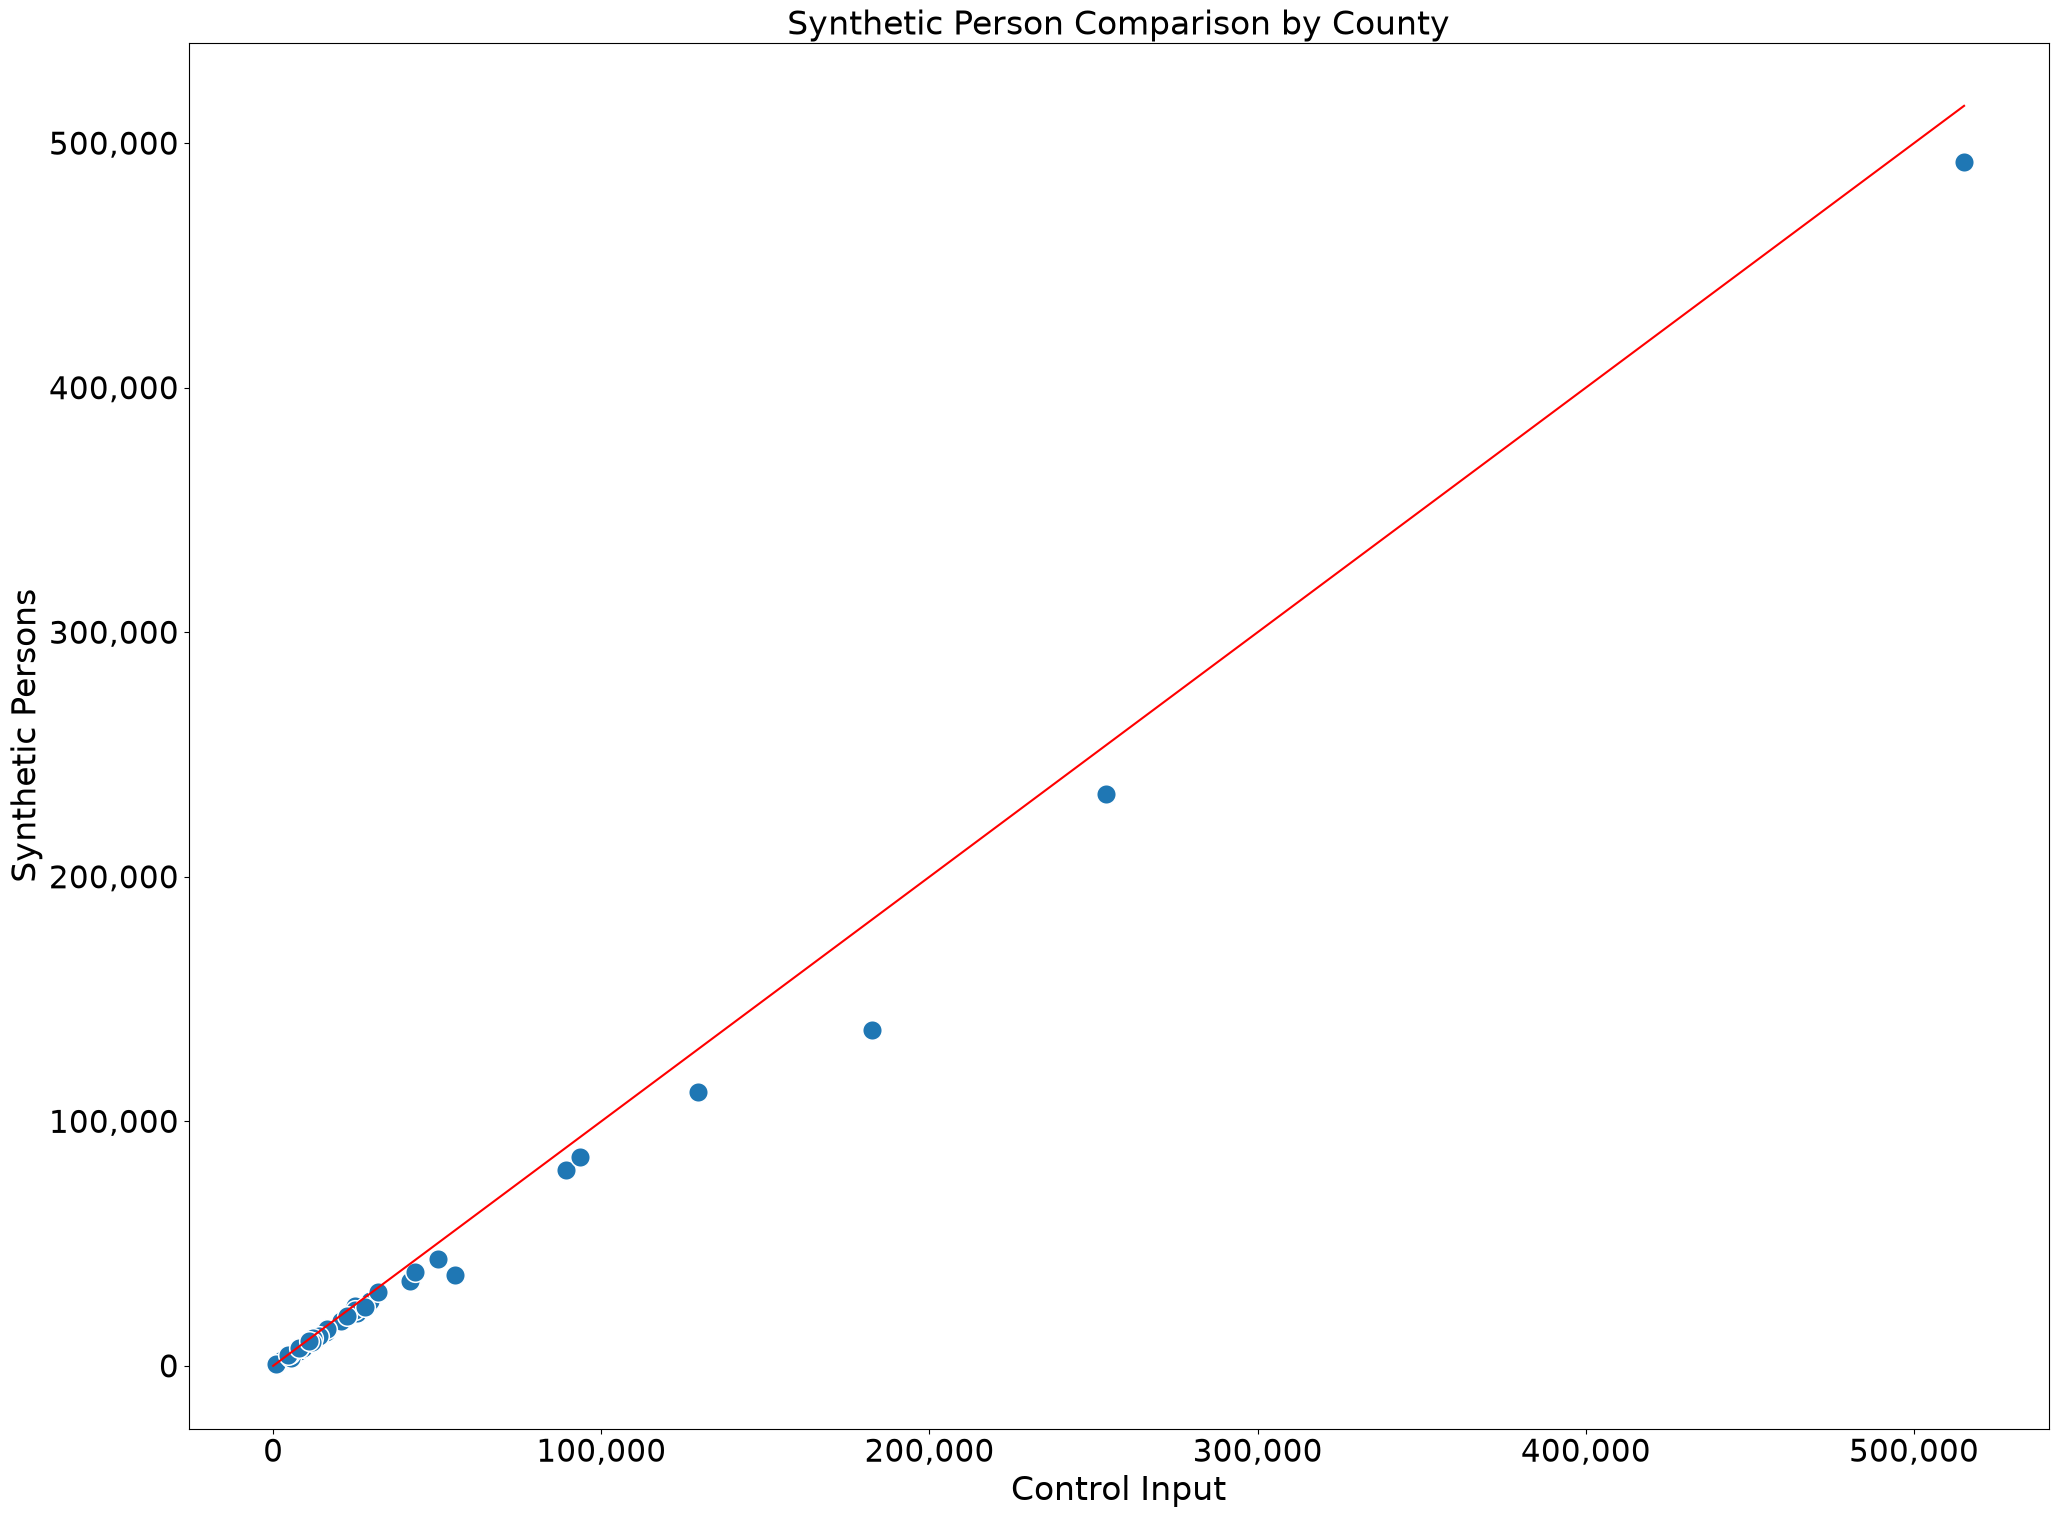

In [12]:
x_pred = np.linspace(0, np.max(np.max(co_pop_compare[['control', 'synper']])), 100)

fig, ax = plt.subplots(figsize=(24, 18))
plot_idx = 111
plt.subplot(plot_idx)
sns.lineplot(x=x_pred, y=x_pred, ax=ax, color = 'red')
# sns.lineplot(x = x_pred, y = poly1d_fn(x_pred), ax = ax, color = 'black', linestyle='dashed')
# sns.lineplot(x = x_pred, y = x_pred + 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
# sns.lineplot(x = x_pred2, y = x_pred2 - 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
sns.scatterplot(data = co_pop_compare, x = 'control', y = 'synper', s = 200) #, c = plot_data['FTYPE'].map(ftype_colors))
# plt.text(60000, 10000, f"$r^2 = {plot_data[['Model', 'Count']].corr()['Model']['Count']**2:.4f}$", fontsize=22)
# plt.text(60000, 7000, f"y = {m:.4f}x {'+' if b >= 0 else ''} {b:,.0f}", fontsize=22)
plt.title(f"Synthetic Person Comparison by County", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.ylabel('Synthetic Persons', fontsize=24)
plt.xlabel('Control Input', fontsize=24)
ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

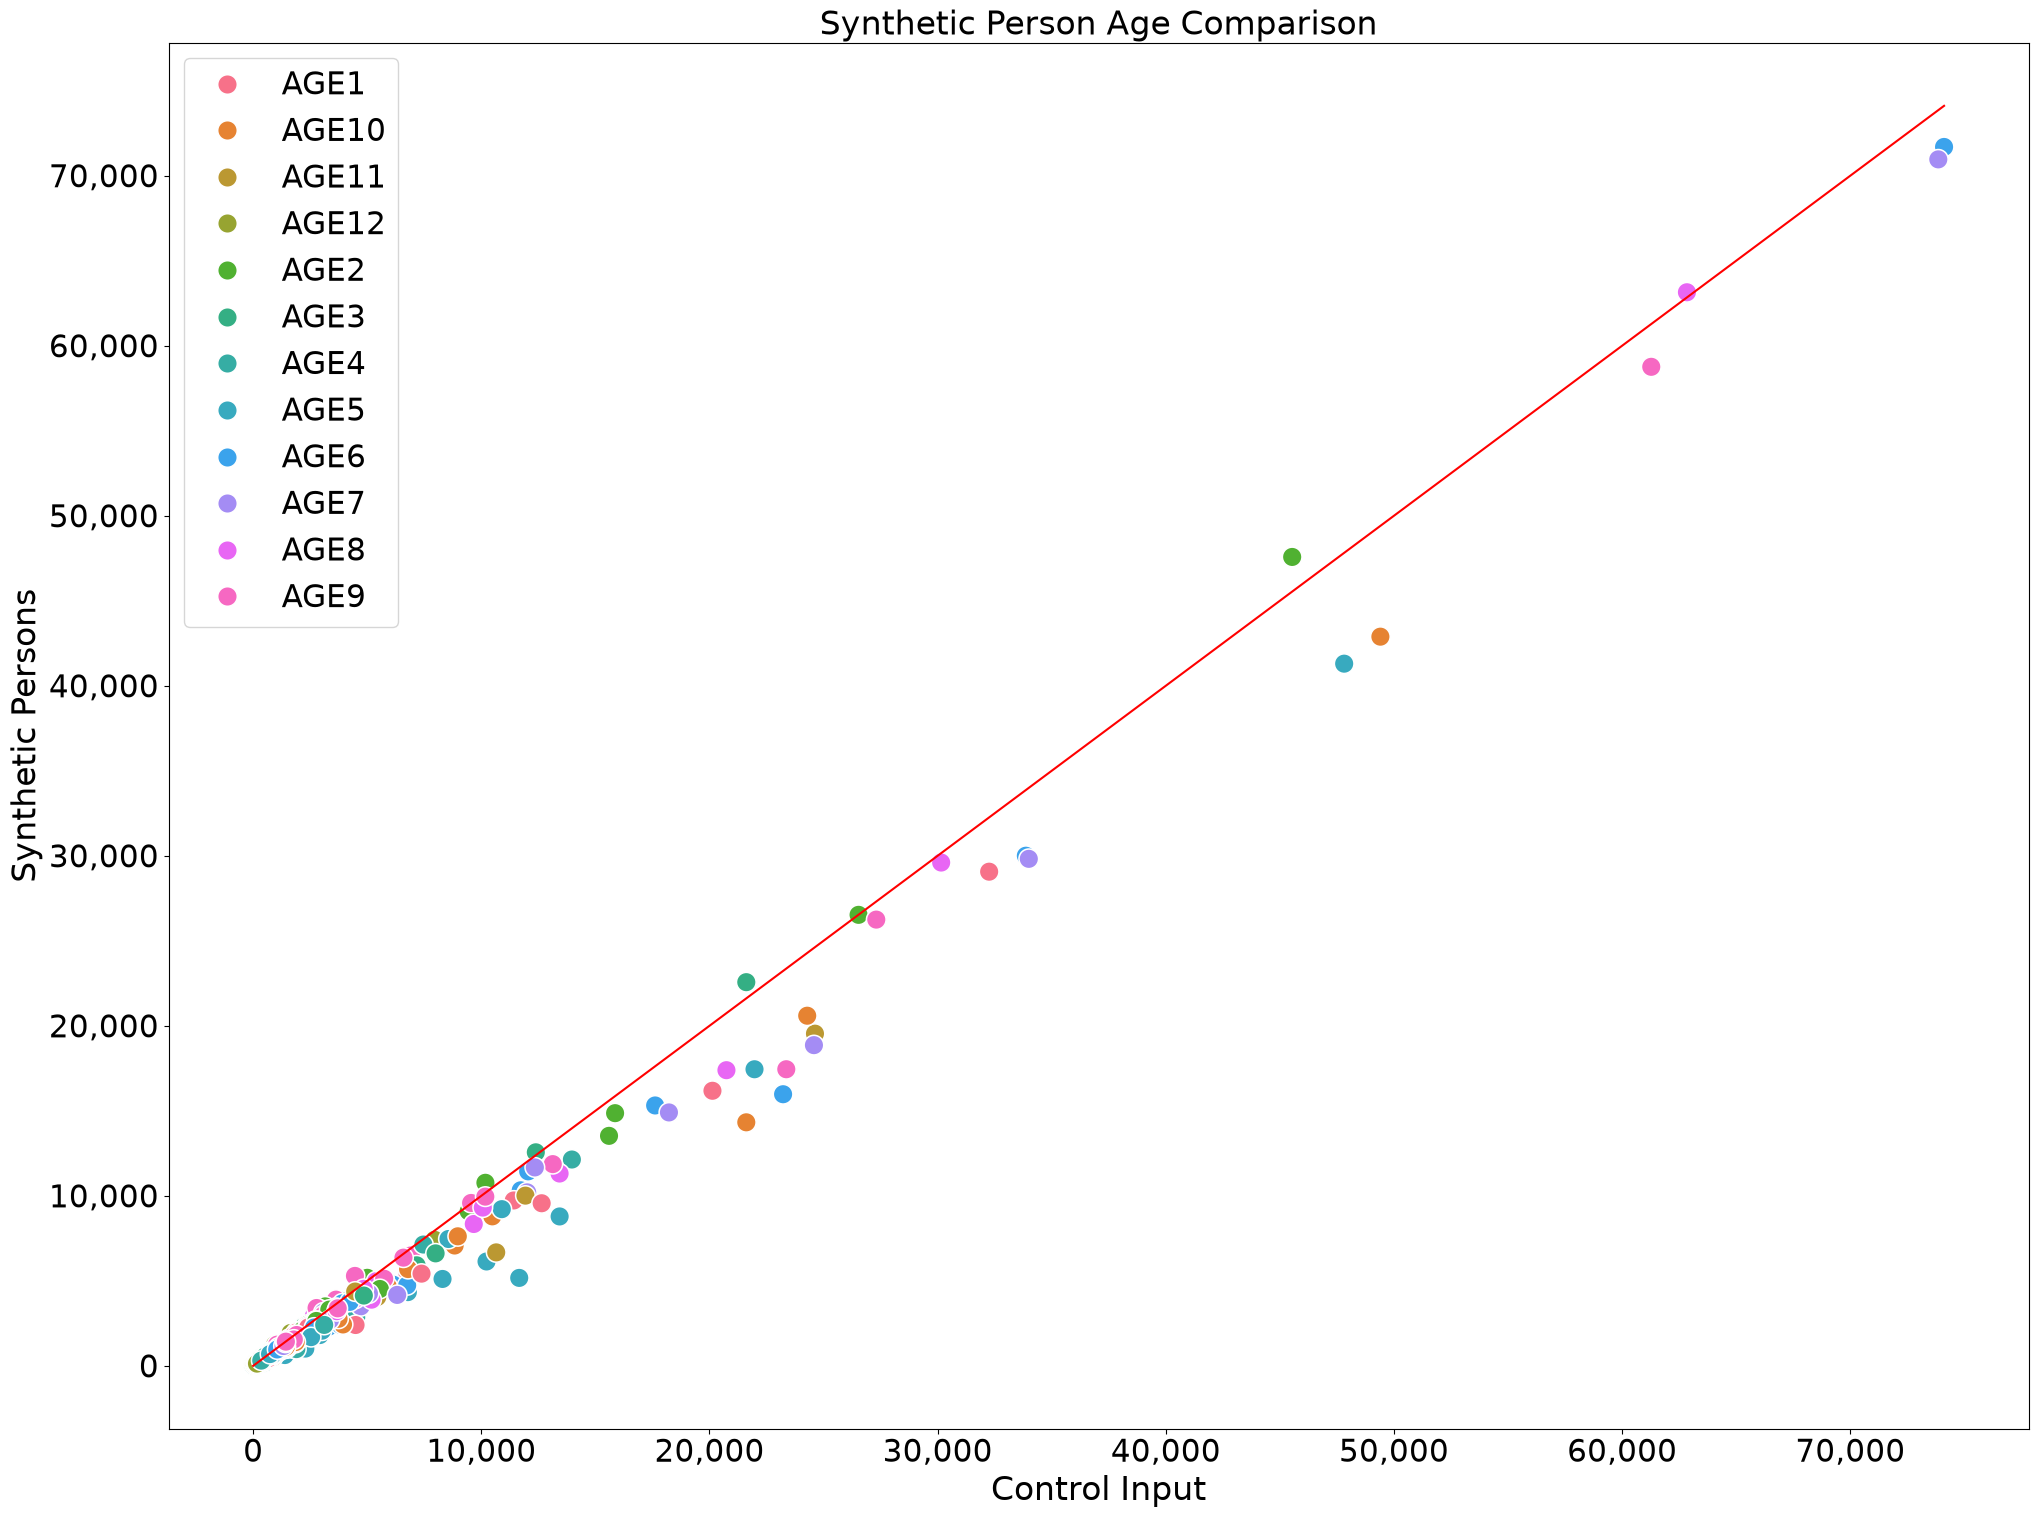

In [13]:
x_pred = np.linspace(0, np.max(np.max(age_compare[['control', 'synper']])), 100)

age_colors = {'AGE1': '#a6cee3', 'AGE2': '#1f78b4', 'AGE3': '#b2df8a', 'AGE4': '#33a02c', 'AGE5': '#fb9a99', 'AGE6': '#e31a1c',
    'AGE7': '#fdbf6f', 'AGE8': '#ff7f00', 'AGE9': '#cab2d6', 'AGE10': '#6a3d9a', 'AGE11': '#ffff99', 'AGE12': '#b15928'}

fig, ax = plt.subplots(figsize=(24, 18))
plot_idx = 111
plt.subplot(plot_idx)
sns.lineplot(x=x_pred, y=x_pred, ax=ax, color = 'red')
# sns.lineplot(x = x_pred, y = poly1d_fn(x_pred), ax = ax, color = 'black', linestyle='dashed')
# sns.lineplot(x = x_pred, y = x_pred + 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
# sns.lineplot(x = x_pred2, y = x_pred2 - 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
sns.scatterplot(data = age_compare, x = 'control', y = 'synper', s = 200, hue = age_compare['AGEGP']) #, c = plot_data['FTYPE'].map(ftype_colors))
# handles = [i for i in np.unique(age_compare['AGEGP'].map(age_colors))]

# plt.text(60000, 10000, f"$r^2 = {plot_data[['Model', 'Count']].corr()['Model']['Count']**2:.4f}$", fontsize=22)
# plt.text(60000, 7000, f"y = {m:.4f}x {'+' if b >= 0 else ''} {b:,.0f}", fontsize=22)
plt.title(f"Synthetic Person Age Comparison", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.ylabel('Synthetic Persons', fontsize=24)
plt.xlabel('Control Input', fontsize=24)
plt.legend(fontsize = 22)
ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()